<a href="https://colab.research.google.com/github/mana1209/b/blob/main/9%E7%AB%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

# Install and import japanize_matplotlib for Japanese font support
# This line should ideally be run once at the beginning of the notebook session.
# If it's already installed, it will just update.
!pip install japanize-matplotlib -q
import japanize_matplotlib # noqa: F401

# Define the tickers for the required instruments
# Nikkei 225: ^N225
# USD/JPY: JPY=X
# Toyota: 7203.T
tickers = ['^N225', 'JPY=X', '7203.T']

# Revert to the original sample period
start_date = '2016-03-30'
end_date = '2021-03-31'

# Download data using yfinance
try:
    # Explicitly select 'Close' prices for all tickers
    df_raw = yf.download(tickers, start=start_date, end=end_date)
    df = df_raw['Close']
except Exception as e:
    print(f"Error downloading data: {e}")
    raise

# Ensure all specified columns are present after download
if not all(ticker in df.columns for ticker in tickers):
    missing_tickers = [ticker for ticker in tickers if ticker not in df.columns]
    raise ValueError(f"Missing data for tickers: {missing_tickers}. Please check ticker symbols or availability.")

# Calculate daily returns
returns = df.pct_change().dropna()

# Assign columns based on tickers for clarity and consistency with previous logic
identified_cols = {
    'nikkei': '^N225',
    'usdjpy': 'JPY=X',
    'toyota': '7203.T'
}

usdjpy_returns = returns[identified_cols['usdjpy']]
nikkei_returns = returns[identified_cols['nikkei']]
toyota_returns = returns[identified_cols['toyota']]

# Calculate 1st and 99th percentiles for Toyota stock returns
lower_bound = toyota_returns.quantile(0.01)
upper_bound = toyota_returns.quantile(0.99)

# Filter for data points where Toyota stock returns are in the top 1% or bottom 1%
extreme_toyota_returns_mask = (toyota_returns <= lower_bound) | (toyota_returns >= upper_bound)
extreme_data = returns[extreme_toyota_returns_mask].copy()

# Separate for plotting: Toyota increase vs decrease
toyota_increase_mask = extreme_data[identified_cols['toyota']] >= upper_bound
toyota_decrease_mask = extreme_data[identified_cols['toyota']] <= lower_bound

/tmp/ipykernel_7833/1125990537.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_7833/1125990537.py:37: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


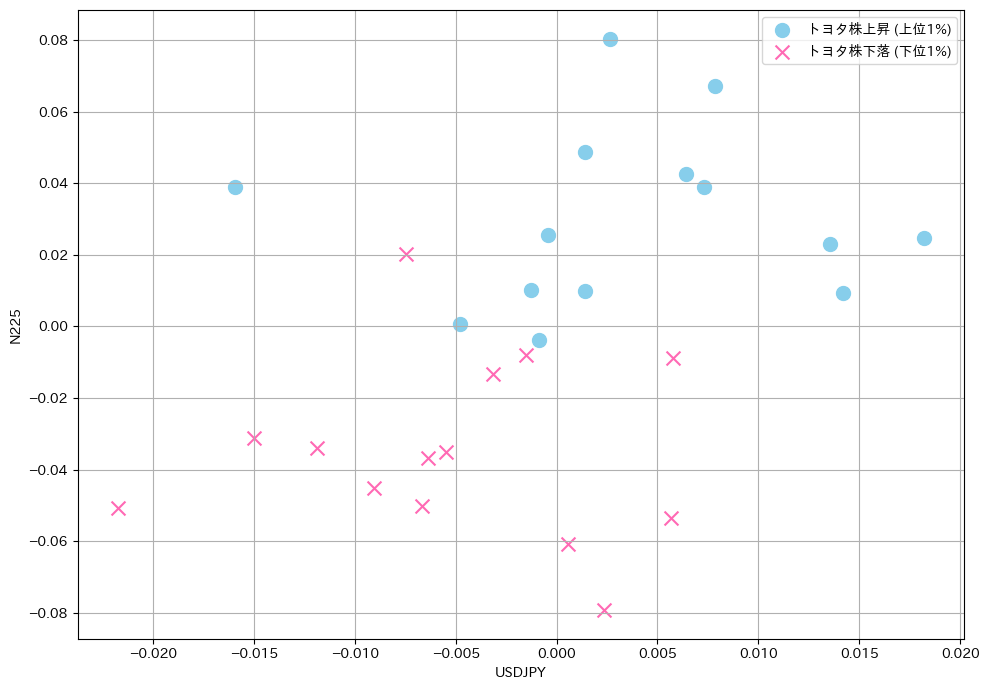

In [ ]:
plt.figure(figsize=(10, 7))

# Plot for Toyota increase (circles)
plt.scatter(
    extreme_data[toyota_increase_mask][identified_cols['usdjpy']],
    extreme_data[toyota_increase_mask][identified_cols['nikkei']],
    marker='o',
    color='skyblue',
    label='トヨタ株上昇 (上位1%)',
    s=100  # Increased size for circles
)

# Plot for Toyota decrease (crosses)
plt.scatter(
    extreme_data[toyota_decrease_mask][identified_cols['usdjpy']],
    extreme_data[toyota_decrease_mask][identified_cols['nikkei']],
    marker='x',
    color='hotpink',
    label='トヨタ株下落 (下位1%)',
    s=100  # Increased size for crosses
)

plt.xlabel('USDJPY')
plt.ylabel('N225')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_7833/451129493.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_7833/451129493.py:35: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


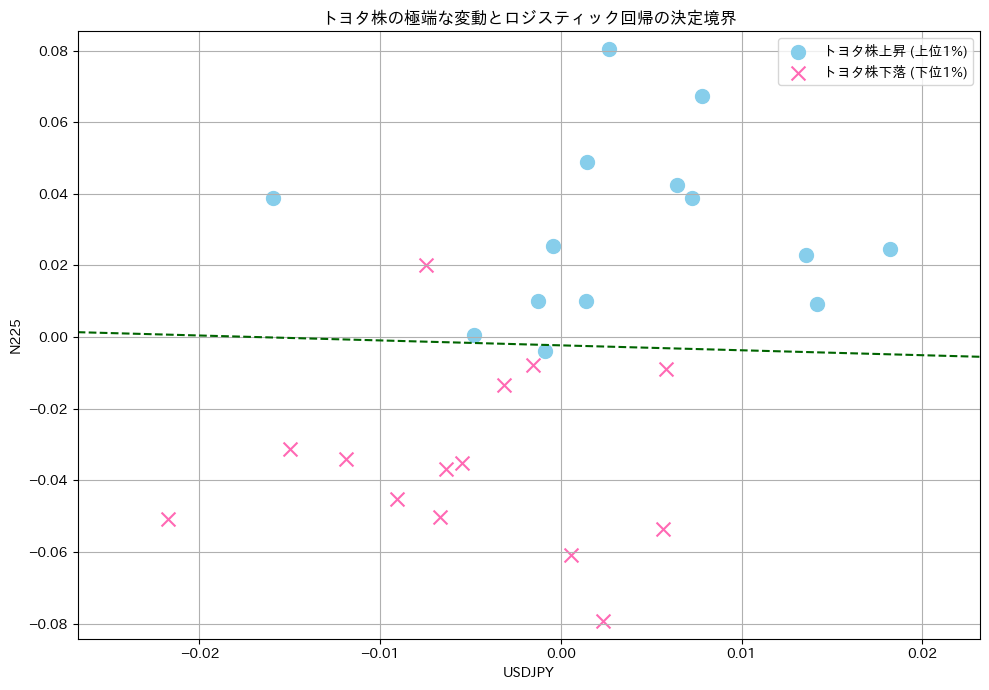

Logistic Regression Coefficients:
USDJPY (coefficient): 0.0613
N225 (coefficient): 0.4459
Intercept: 0.0010


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from sklearn.linear_model import LogisticRegression

# Install and import japanize_matplotlib for Japanese font support
# This line should ideally be run once at the beginning of the notebook session.
# If it's already installed, it will just update.
!pip install japanize-matplotlib -q # Uncommented to install the package
import japanize_matplotlib # noqa: F401

# Define the tickers for the required instruments
tickers = ['^N225', 'JPY=X', '7203.T']

# Revert to the original sample period
start_date = '2016-03-30'
end_date = '2021-03-31'

# Download data using yfinance
try:
    # Explicitly select 'Close' prices for all tickers
    df_raw = yf.download(tickers, start=start_date, end=end_date)
    df = df_raw['Close']
except Exception as e:
    print(f"Error downloading data: {e}")
    raise

# Ensure all specified columns are present after download
if not all(ticker in df.columns for ticker in tickers):
    missing_tickers = [ticker for ticker in tickers if ticker not in df.columns]
    raise ValueError(f"Missing data for tickers: {missing_tickers}. Please check ticker symbols or availability.")

# Calculate daily returns
returns = df.pct_change().dropna()

# Assign columns based on tickers for clarity and consistency with previous logic
identified_cols = {
    'nikkei': '^N225',
    'usdjpy': 'JPY=X',
    'toyota': '7203.T'
}

usdjpy_returns = returns[identified_cols['usdjpy']]
nikkei_returns = returns[identified_cols['nikkei']]
toyota_returns = returns[identified_cols['toyota']]

# Calculate 1st and 99th percentiles for Toyota stock returns
lower_bound = toyota_returns.quantile(0.01)
upper_bound = toyota_returns.quantile(0.99)

# Filter for data points where Toyota stock returns are in the top 1% or bottom 1%
extreme_toyota_returns_mask = (toyota_returns <= lower_bound) | (toyota_returns >= upper_bound)
extreme_data = returns[extreme_toyota_returns_mask].copy()

# Separate for plotting: Toyota increase vs decrease
toyota_increase_mask = extreme_data[identified_cols['toyota']] >= upper_bound
toyota_decrease_mask = extreme_data[identified_cols['toyota']] <= lower_bound

# Prepare features (X)
X = extreme_data[[identified_cols['usdjpy'], identified_cols['nikkei']]]

# Prepare target variable (y)
y = np.zeros(len(extreme_data))
y[toyota_increase_mask] = 1 # Toyota stock increased (top 1%)
# y remains 0 for toyota_decrease_mask (bottom 1%)

# Initialize and fit Logistic Regression model with class_weight='balanced'
# This will automatically adjust weights inversely proportional to class frequencies
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
model.fit(X, y)

# Create a meshgrid for plotting the decision boundary
# Expand the min/max slightly to ensure the boundary covers the full plot area
x_min, x_max = X[identified_cols['usdjpy']].min() - 0.005, X[identified_cols['usdjpy']].max() + 0.005
y_min, y_max = X[identified_cols['nikkei']].min() - 0.005, X[identified_cols['nikkei']].max() + 0.005
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict probabilities on the meshgrid to find the decision boundary
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plotting the decision boundary along with the original scatter points
plt.figure(figsize=(10, 7))

# Plot for Toyota increase (circles)
plt.scatter(
    extreme_data[toyota_increase_mask][identified_cols['usdjpy']],
    extreme_data[toyota_increase_mask][identified_cols['nikkei']],
    marker='o',
    color='skyblue',
    label='トヨタ株上昇 (上位1%)',
    s=100
)

# Plot for Toyota decrease (crosses)
plt.scatter(
    extreme_data[toyota_decrease_mask][identified_cols['usdjpy']],
    extreme_data[toyota_decrease_mask][identified_cols['nikkei']],
    marker='x',
    color='hotpink',
    label='トヨタ株下落 (下位1%)',
    s=100
)

# Plot the decision boundary (where Z = 0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='darkgreen', linestyles='--')

plt.xlabel('USDJPY')
plt.ylabel('N225')
plt.title('トヨタ株の極端な変動とロジスティック回帰の決定境界')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print model coefficients and intercept for interpretation
print("Logistic Regression Coefficients:")
print(f"USDJPY (coefficient): {model.coef_[0][0]:.4f}")
print(f"N225 (coefficient): {model.coef_[0][1]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

決定境界より上側に日経平均と為替レートの変化率が位置したらトヨタの株価が上がるし、下側なら下がるという推測

もし日経平均と為替レートの変化率が決定境界上にあるとき、トヨタの株は50％の確率で上がり、50％の確率で下がることを意味する。

**ディープラーニングの基本的な仕組み**

  $ある株式のリターンR,指数のリターンR_{M}に対して、事象E＝\{R\geq R_{M}\}とE^c=\{R<R_{M}\}を定義する。$

$そして1時点後にこれらの事象が起きるかどうかの予測器で\hat{P},\hat{P}(E^c)を求める。$

$この予測器を求めるために、p=\hat{P}(E)と特徴量xをある関数f(・)でp=f(x)と関係づける。$

$特徴量のデータ\{x_{n}\}_{n=0,...,N-1}を関数f(・)に入力して得られるp_n=f(X_n)を計算する。$

$そして、特徴量のサンプルx_nをサンプリングした時点からみて1時点後にEが生じたらy_n=1,E^cが生じたらy_n=0となるようにy_nのサンプルを作っていく。$

$これらのサンプル\{(p_n,y_n)\}_{n=0,...,N-1}を使って公差エントロピー誤差の総和$

$-\sum_{n=0}^{N-1}y_n\log p_n-\sum_{n=0}^{N-1}(1-y_n)\log(1-p_n)$

$を計算する。関数P=f(x)をこの交差エントロピー誤差の総和が最小になるように決める。$

$ロジスティック回帰の場合、重みパラメータwとロジスティック・シグモイド関数を使って、p=f_\sigma(w^\mathsf{T}x)とする。$

$ディープラーニングではp=p=f_\sigma(w^\mathsf{T}z)とする。zは活性化関数と呼ばれる非線形な関数h(・)によりz=h(a)で与えられる。$

Zの最初の要素はZ_0=1である。また、a=Wx

**ニューラルネットワークの構造**

$入力層：分析したいデータ（特徴量ｘ）を最初に入れる場所\\
隠れ層（第1～Ｌ層）：入力されたデータを複雑に計算・加工する中間ステージ\\
出力層：最終的な予測結果pを出す場所$

$出力層：p=f_\sigma(w^\mathsf{T}z_L)\\
第L層:z_L=h_L(a_L),a_L=W_LZ_{L-1}\\
\vdots\\
第1層:z_1=h_1(a_1),a_1=W_1x\\
入力層:特徴量ｘを与える$

$前の層から届いたデータに、それぞれの重みを掛け算して足し合わせる（a=W_xの部分）。\\
↓\\
足し合わせた数値をそのまま使うのではなく、活性化関数に通して次の層に引き継ぐために都合の良い形に変換する(z=h(a)の部分)$

$「この重みをかけて足す→関数で変換する」というセットを第1層から最後の出力層まで繰り返して最終的な予測値pを導き出す。\\
この予測値pと実際の正しい答えの間のズレ(交差エントロピー誤差)を最小化したい。$

$l_L(w,W_L,...,W_1)=-\sum_{n=0}^{N-1}y_n\log p_n(w,W_L,...,W_1)-\sum_{n=0}^{N-1}(1-y_n)\log (1-p_n(w,W_L,...,W_1))$

**確率的勾配降下法**

$パラメータ(w,W_L,...,W_1)の要素を並べてベクトルにしたw_Lを用いて式を書き換える。\\
l_L(w_L)=-\sum_{n=0}^{N-1}y_n\log p_n(w_L)-\sum_{n=0}^{N-1}(1-y_n)\log (1-p_n(w_L))\\
1.重みパラメータの初期値w_L^{(0)}を与える\\
2.交差エントロピー誤差関数l_L(w_L)の勾配\\
\nabla l_L=\begin{pmatrix}
  \delta l_L(w_L)/\delta w_0  \\\vdots\\ \delta l_L(w_L)/\delta w_j  
\end{pmatrix}\\
を計算する\\
3.重みパラメータを以下のように更新する\\
w_L^{(\tau+1)}=w_L^{(\tau)}-\eta\nabla l_L\\
ここで\etaは学習率、\tau=0,1,...はパラメータの更新回数である。
$

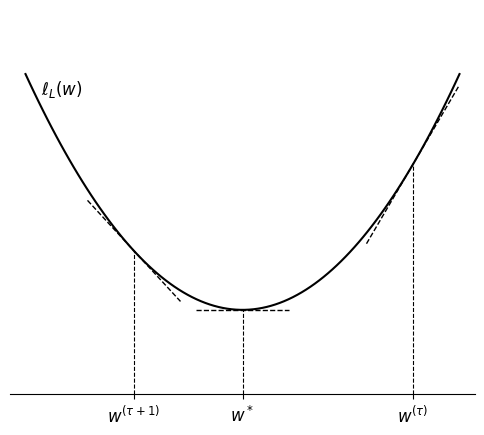

In [ ]:
# 1. 日本語表示用のライブラリをインストール
!pip install japanize-matplotlib

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 2. 誤差関数（二次関数）と勾配（傾き）の定義
def loss_func(w):
    return (w - 2)**2 + 0.5

def gradient(w):
    return 2 * (w - 2)

# 3. グラフ用のデータ作成
w = np.linspace(0.6, 3.4, 100)
l_w = loss_func(w)

# 各パラメータの定義点（最小値 w* の左側に w_next を配置）
w_star = 2.0
w_tau = 3.1
w_next = 1.3  # w* より左、w_tau よりもしっかり左へ移動

# 4. グラフのプロット
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(w, l_w, color='black', linewidth=1.5)

# 各点から横軸への垂直な破線
ax.vlines(w_star, -0.2, loss_func(w_star), colors='black', linestyles='dashed', linewidth=0.8)
ax.vlines(w_tau, -0.2, loss_func(w_tau), colors='black', linestyles='dashed', linewidth=0.8)
ax.vlines(w_next, -0.2, loss_func(w_next), colors='black', linestyles='dashed', linewidth=0.8)

# 3箇所に接線（点線）を描画
for w_pos in [w_next, w_star, w_tau]:
    # 各点のまわり0.3の幅で接線を描く
    t_w = np.linspace(w_pos - 0.3, w_pos + 0.3, 50)
    t_l = loss_func(w_pos) + gradient(w_pos) * (t_w - w_pos)
    ax.plot(t_w, t_l, color='black', linestyle='dashed', linewidth=1)

# 5. グラフの見た目・レイアウト調整
ax.set_xlim(0.5, 3.5)
ax.set_ylim(-0.2, 3.0)

# 目盛り（ラベル）の設定
ax.set_xticks([w_next, w_star, w_tau])
ax.set_xticklabels([r'$w^{(\tau+1)}$', r'$w^*$', r'$w^{(\tau)}$'], fontsize=12)
ax.set_yticks([]) # Y軸の目盛り数値は非表示に

# 不要な枠線（上・右・左）を消す
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# 数式ラベルの追加
ax.text(0.7, loss_func(0.7) + 0.1, r'$\ell_L(w)$', fontsize=12)

# 表示
plt.show()


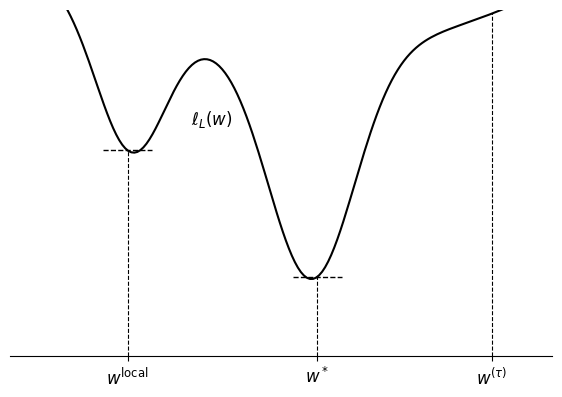

In [ ]:
# 1. 日本語表示用のライブラリをインストール
!pip install japanize-matplotlib

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 2. 非凸誤差関数の定義
def loss_func_nonconvex(w):
    return (3.5
            - 1.8 * np.exp(-((w - 2.5) / 0.8)**2)  # 左の浅い谷
            - 3.0 * np.exp(-((w - 5.5) / 1.0)**2)  # 中央の深い谷
            + 0.05 * (w - 5.5)**2)                 # 全体の緩やかな傾き

# 3. グラフ用のデータ作成
w = np.linspace(0, 10, 200)
l_w = loss_func_nonconvex(w)

# 特徴的な3つの点の位置を定義
w_local = 2.45   # 局所最適解
w_star = 5.6     # 大域的最適解
w_tau = 8.5      # 台地（プラトー）

# 4. グラフのプロット
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(w, l_w, color='black', linewidth=1.5)

# 各点から横軸への垂直な破線（3箇所すべてに引きます）
ax.vlines(w_local, -0.5, loss_func_nonconvex(w_local), colors='black', linestyles='dashed', linewidth=0.8)
ax.vlines(w_star, -0.5, loss_func_nonconvex(w_star), colors='black', linestyles='dashed', linewidth=0.8)
ax.vlines(w_tau, -0.5, loss_func_nonconvex(w_tau), colors='black', linestyles='dashed', linewidth=0.8)

# 2箇所（w_local, w_star）だけに完全に水平な接線（点線）を描画
for w_pos in [w_local, w_star]:
    t_w = np.linspace(w_pos - 0.4, w_pos + 0.4, 50)
    t_l = np.full_like(t_w, loss_func_nonconvex(w_pos)) # 高さを揃えて水平にする
    ax.plot(t_w, t_l, color='black', linestyle='dashed', linewidth=1)

# 5. グラフの見た目・レイアウト調整
ax.set_xlim(0.5, 9.5)
ax.set_ylim(-0.5, 4.0)

# 目盛り（ラベル）の設定
ax.set_xticks([w_local, w_star, w_tau])
ax.set_xticklabels([r'$w^{\mathrm{local}}$', r'$w^*$', r'$w^{(\tau)}$'], fontsize=12)
ax.set_yticks([]) # Y軸の目盛り数値は非表示に

# 不要な枠線削除
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# 数式ラベルの追加
ax.text(3.5, 2.5, r'$\ell_L(w)$', fontsize=12)

# 表示
plt.show()


$勾配降下法を用いる場合、初期値の設定次第でw^{local}のような局所最適解にたどり着くことがある。\\このような問題に対処するために用いられるのが確率的勾配降下法である。$

$確率的勾配降下法では、データを一つランダムに抽出し、そのデータから得られる誤差から勾配を計算しパラメータを更新する。\\
w_L^{(\tau+1)}=w_L^{(\tau)}-\eta\nabla l_n$

$逐次学習：データを一つずつ順番に読み込んでその都度パラメータを更新していく方法\\
バッチ学習：すべてのデータを一度にまとめて計算しパラメータを更新していく方法\\
$

**誤差逆伝播法**

$出力層→隠れ層→入力層へとさかのぼって計算する方法。\\
第l層の重み(W_l)の勾配を計算する式\\
\frac{\partial l_n}{\partial W_l}=\delta_l{z_{l-1}}^\mathsf{T}\\
\delta_l=第l層のエラー\\
{z_{l-1}}^\mathsf{T}=第l-1層からの出力\\
ここで\delta_lは総入力a_lが変化した時に全体の誤差l_nがどれくらい変化するか\\
\delta_l=\frac{\partial l_n}{\partial a_l}
\\
と定義される。\\
さらに、ある層の\delta_lは次の層の\delta_{l+1}によって以下のように定義される。\\
\delta_l^\mathsf{T}=\delta^\mathsf{T}_{l+1}W_{l+1}=\frac{\partial h_l(a_l)}{\partial a_l}
\\
$